## Solving the Steady-State Radiative Transfer Equation (RTE/RFE) using Vanilla-PINNs

In this notebook, we solve the steady-state 1D Radiative Transfer Equation (RTE) using a **VANILLA-PINN** approach.
Boundary conditions are enforced exactly by construction using indicator functions.


### Case 1 (1D) 
We first focus on a simple case , which is a 1D space + 1D direction test case with the following configuration :
* **Geometry:** $0 \le x \le L_x$ with $L_x = 1.0\text{ m}$.
* **Equation (1D RTE):**
  $$\mu \frac{\partial I}{\partial x} + (\kappa + \sigma(x)) I(x, \mu) = \frac{\sigma(x)}{2} \int_{-1}^{1} I(x, \mu') d\mu'$$
* **Physical Properties:**
  * Absorption coefficient: $\kappa = 0$ (Non-absorbing medium).
  * Scattering coefficient: $\sigma(x) = \frac{1}{x}$.
* **Boundary Conditions (BC):**
  * At $x = 0$ (for incoming directions $\mu > 0$): $I(0, \mu) = 1$
  * At $x = L_x = 1$ (for incoming directions $\mu < 0$): $I(1, \mu) = 0$


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

## 1. PINN Architecture Definition
Definition of the standard Neural Network (Multi-Layer Perceptron) to approximate the solution $u(t,x)$.

In [2]:
class PinnRFEEq(nn.Module):
    def __init__(self):
        super().__init__()
        self.couche_entree = nn.Linear(2, 100)
        self.couche_cachee1 = nn.Linear(100, 100)
        self.couche_cachee2 = nn.Linear(100, 100)
        self.couche_cachee3 = nn.Linear(100, 100)
        self.couche_cachee4 = nn.Linear(100, 100)
        self.couche_sortie = nn.Linear(100, 1)

    def forward(self, x):
        x = torch.tanh(self.couche_entree(x))
        x = torch.tanh(self.couche_cachee1(x))
        x = torch.tanh(self.couche_cachee2(x))
        x = torch.tanh(self.couche_cachee3(x))
        x = torch.tanh(self.couche_cachee4(x))
        return self.couche_sortie(x)


## 2. Sampling and Collocation Points Generation
Functions to generate collocation points (in the domain) ,and boundary points ($x=0$ and $x=1$).

In [3]:
mu_min, mu_max = -1.0, 1.0
x_min, x_max = 0.0, 1.0


def generer_points_collocation(n_pde):
    mu_colloc = torch.rand(n_pde, 1) * (mu_max - mu_min) + mu_min
    x_colloc = torch.rand(n_pde, 1) * (x_max - x_min) + x_min
    return mu_colloc.float(), x_colloc.float()



def generer_points_bords(n_bords):                                                                       
    n_half = n_bords // 2                                                                                
                                                                                                             
    x_gauche = torch.zeros(n_half, 1)                                                                    
    mu_gauche = torch.rand(n_half, 1)                                                 
                                                                                                             
    x_droite = torch.ones(n_half, 1)                                                                     
    mu_droite = -torch.rand(n_half, 1)                                            
                                                                                                             
    return x_gauche.float(), mu_gauche.float(), x_droite.float(), mu_droite.float()   

## 3. Loss Functions Definition
Grouping of loss calculation functions for initial conditions (IV), boundary conditions (BC), and the PDE residual (CLP).

In [4]:
def calc_bc_loss(model, x_g, mu_g, x_d, mu_d):                                                           
                                                                                                             
    inputs_gauche = torch.cat([x_g, mu_g], dim=1)                                            
    inputs_droite = torch.cat([x_d, mu_d], dim=1)                                             
                                                                                     
    pred_gauche = model(inputs_gauche)                                                                   
    pred_droite = model(inputs_droite)                                                                   
                                                                                                             
    loss_bc_gauche = torch.mean((pred_gauche - 1.0) ** 2)                                                
    loss_bc_droite = torch.mean((pred_droite - 0.0) ** 2)                                                
                                                                                                             
    return loss_bc_gauche + loss_bc_droite           

def calc_clp_loss(model, mu_colloc, x_colloc):
    mu_colloc.requires_grad_(True)
    x_colloc.requires_grad_(True)

    I_pred = model(torch.cat([x_colloc, mu_colloc], dim=1))

    
    I_x = torch.autograd.grad(
        outputs=I_pred,
        inputs=x_colloc,
        grad_outputs=torch.ones_like(I_pred),
        create_graph=True,
    )[0]

    N = x_colloc.shape[0]                                                                                    
                                                                                                             
    x_expanded = x_colloc.repeat(1, N_quadrature)                                                                     
                                                                                                             
    mu_expanded = quad_mu.t().repeat(N, 1)                                                                   
                                                                                                             
                                                                                   
    inputs = torch.cat([x_expanded.flatten().view(-1, 1), mu_expanded.flatten().view(-1, 1)], dim=1)         
    I_quad_preds = model(inputs).view(N, N_quadrature)                                               
                                                                                                                                                                                  
    integral = torch.sum(I_quad_preds * quad_w.t(), dim=1, keepdim=True)
    sigma_x = 1.0 / x_colloc                                                                

    pde_residual = mu_colloc * I_x + sigma_x * I_pred - 0.5 * sigma_x * integral
    loss_pde = torch.mean(pde_residual ** 2) 

    return loss_pde

## 4. Hardware (Device), Model, and Optimizer Initialization
Hardware detection, model creation, and optimizer definition.

In [5]:
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(device)

mu_colloc, x_colloc = generer_points_collocation(12000)


mu_colloc, x_colloc = mu_colloc.to(device), x_colloc.to(device)
n_bords = 1000
x_g, mu_g, x_d, mu_d = generer_points_bords(n_bords) 
x_g = x_g.to(device)                                                                                     
mu_g = mu_g.to(device)                                                                                   
x_d = x_d.to(device)                                                                                     
mu_d = mu_d.to(device)                                                                                   
                                                                                                             

mps


In [6]:
N_quadrature = 16
nodes, weights = np.polynomial.legendre.leggauss(N_quadrature)                                                    
                                                                                                             
quad_mu = torch.tensor(nodes, dtype=torch.float32).view(N_quadrature, 1).to(device)                     
quad_w = torch.tensor(weights, dtype=torch.float32).view(N_quadrature, 1).to(device)


## 5. Model Training
Training phase of the PINN model using the defined optimizers (Adam and/or L-BFGS).

In [7]:
modele = PinnRFEEq().to(device)
optimizer = optim.Adam(modele.parameters(), lr=1e-3)

epochs = 5000

for epoch in range(epochs):
    optimizer.zero_grad()
    loss_bc = calc_bc_loss(modele, x_g, mu_g, x_d, mu_d)   
    loss_clp = calc_clp_loss(modele, mu_colloc, x_colloc)
    loss_totale = 10.0 * loss_bc + loss_clp
    loss_totale.backward()
    optimizer.step()

    if epoch % 100 == 0:
        print(f"Epoque {epoch:05d} | "
              f"Loss totale: {loss_totale.item():.2e} | "
              f"CLP: {loss_clp.item():.2e} | "
              f"BC: {loss_bc.item():.2e} | "
              )

def closure():
    optimizer.zero_grad()
    loss_bc = calc_bc_loss(modele, x_g, mu_g, x_d, mu_d)
    loss_clp = calc_clp_loss(modele, mu_colloc, x_colloc)
    loss_totale = 10.0 * loss_bc + loss_clp
    loss_totale.backward()
    return loss_totale

lbfgs_epochs = 1000
optimizer = optim.LBFGS(modele.parameters(), line_search_fn="strong_wolfe", max_iter=20)
for epoch in range(lbfgs_epochs):
    loss = optimizer.step(closure)
    if epoch % 100 == 0:
        print(f"Epoque LBFGS {epoch:05d} | "
              f"Loss totale: {loss.item():.2e}")


Epoque 00000 | Loss totale: 1.50e+01 | CLP: 2.28e+00 | BC: 1.27e+00 | 
Epoque 00100 | Loss totale: 3.18e-01 | CLP: 3.03e-01 | BC: 1.46e-03 | 
Epoque 00200 | Loss totale: 2.51e-01 | CLP: 2.37e-01 | BC: 1.42e-03 | 
Epoque 00300 | Loss totale: 2.14e-01 | CLP: 2.01e-01 | BC: 1.34e-03 | 
Epoque 00400 | Loss totale: 2.01e-01 | CLP: 1.87e-01 | BC: 1.42e-03 | 
Epoque 00500 | Loss totale: 1.79e-01 | CLP: 1.59e-01 | BC: 1.99e-03 | 
Epoque 00600 | Loss totale: 1.62e-01 | CLP: 1.37e-01 | BC: 2.47e-03 | 
Epoque 00700 | Loss totale: 1.77e-01 | CLP: 1.56e-01 | BC: 2.08e-03 | 
Epoque 00800 | Loss totale: 1.57e-01 | CLP: 1.32e-01 | BC: 2.47e-03 | 
Epoque 00900 | Loss totale: 1.40e-01 | CLP: 1.15e-01 | BC: 2.54e-03 | 
Epoque 01000 | Loss totale: 1.24e-01 | CLP: 1.01e-01 | BC: 2.36e-03 | 
Epoque 01100 | Loss totale: 1.59e-01 | CLP: 1.41e-01 | BC: 1.80e-03 | 
Epoque 01200 | Loss totale: 1.31e-01 | CLP: 1.09e-01 | BC: 2.21e-03 | 
Epoque 01300 | Loss totale: 1.15e-01 | CLP: 9.44e-02 | BC: 2.03e-03 | 
Epoque

KeyboardInterrupt: 

## 6. Visualizing the Results
Comparison of the solution learned by the PINN with the exact analytical solution of the heat equation.

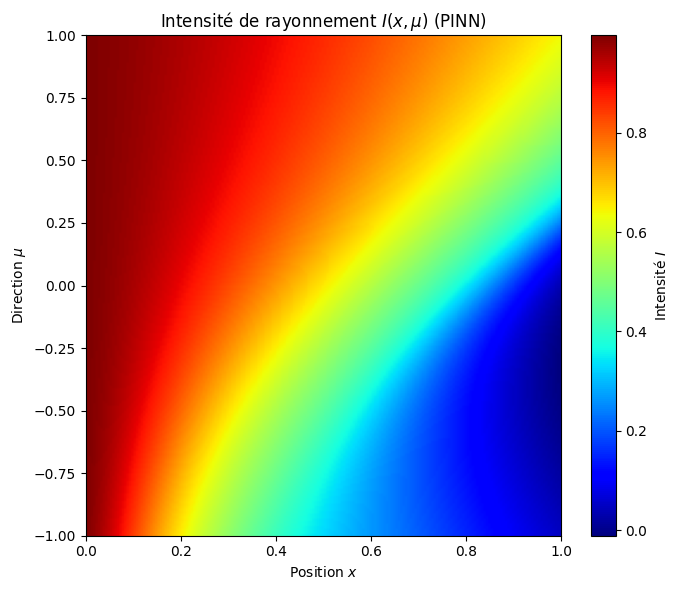

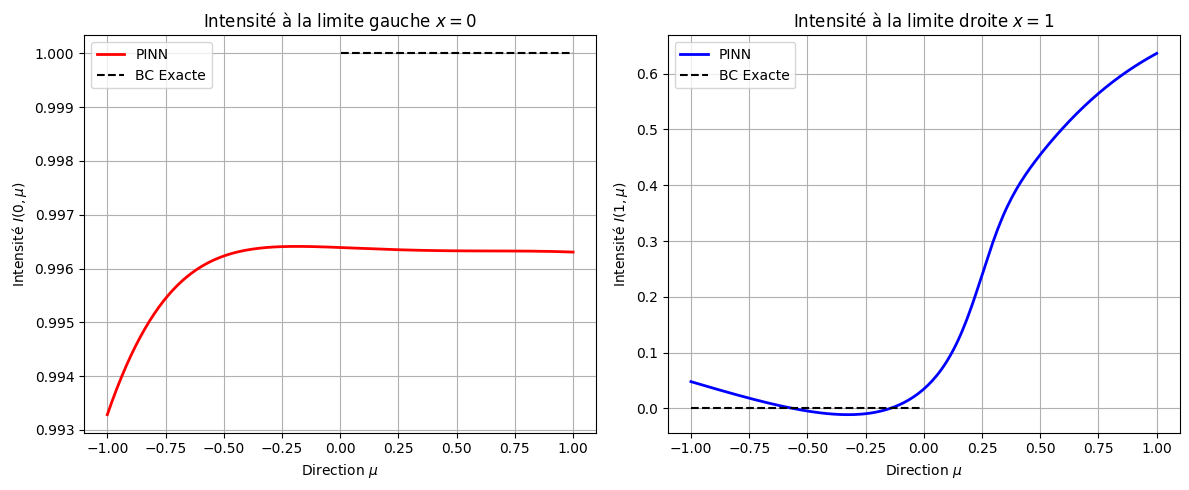

In [8]:

x_vals = np.linspace(0.0, 1.0, 200)
mu_vals = np.linspace(-1.0, 1.0, 200)
X, MU = np.meshgrid(x_vals, mu_vals)


grid_inputs = torch.tensor(np.stack([X.ravel(), MU.ravel()], axis=1), dtype=torch.float32).to(device)
with torch.no_grad():
    I_pred = modele(grid_inputs).cpu().numpy().reshape(X.shape)


fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(I_pred, cmap='jet', aspect='auto', origin='lower',
               extent=[0.0, 1.0, -1.0, 1.0])
ax.set_title("Intensité de rayonnement $I(x, \\mu)$ (PINN)")
ax.set_xlabel("Position $x$")
ax.set_ylabel("Direction $\\mu$")
fig.colorbar(im, label="Intensité $I$")
plt.tight_layout()
fig.savefig("intensity_heatmap.png", dpi=150)
plt.show()


fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# À x = 0
inputs_x0 = torch.tensor(np.stack([np.zeros_like(mu_vals), mu_vals], axis=1), dtype=torch.float32).to(device)
with torch.no_grad():
    I_x0 = modele(inputs_x0).cpu().numpy().flatten()
axes[0].plot(mu_vals, I_x0, label="PINN", color="red", linewidth=2)
axes[0].plot(mu_vals[mu_vals > 0], np.ones_like(mu_vals[mu_vals > 0]), color="black", linestyle="--", label="BC Exacte")
axes[0].set_title("Intensité à la limite gauche $x = 0$")
axes[0].set_xlabel("Direction $\\mu$")
axes[0].set_ylabel("Intensité $I(0, \\mu)$")
axes[0].grid(True)
axes[0].legend()

# À x = 1
inputs_x1 = torch.tensor(np.stack([np.ones_like(mu_vals), mu_vals], axis=1), dtype=torch.float32).to(device)
with torch.no_grad():
    I_x1 = modele(inputs_x1).cpu().numpy().flatten()
axes[1].plot(mu_vals, I_x1, label="PINN", color="blue", linewidth=2)

axes[1].plot(mu_vals[mu_vals < 0], np.zeros_like(mu_vals[mu_vals < 0]), color="black", linestyle="--", label="BC Exacte")
axes[1].set_title("Intensité à la limite droite $x = 1$")
axes[1].set_xlabel("Direction $\\mu$")
axes[1].set_ylabel("Intensité $I(1, \\mu)$")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
fig.savefig("intensity_boundaries.png", dpi=150)
plt.show()


## 7. Exact Numerical Solver Comparison (Discrete Ordinates Method - DOM)
To verify the correctness of the PINN solution for Case 1, we implement the Discrete Ordinates Method (DOM) with Source Iteration as the mathematical/numerical reference solver. We compare the incident radiation $G(x) = \int_{-1}^1 I(x, \mu) d\mu$ and the boundary/internal intensity profiles.

<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:81: SyntaxWarning: invalid escape sequence '\m'
<>:93: SyntaxWarning: invalid escape sequence '\m'
<>:69: SyntaxWarning: invalid escape sequence '\m'
<>:81: SyntaxWarning: invalid escape sequence '\m'
<>:93: SyntaxWarning: invalid escape sequence '\m'
/var/folders/5n/7ytsr0b53qj2zwm2hptdm0f80000gn/T/ipykernel_53776/818363594.py:69: SyntaxWarning: invalid escape sequence '\m'
  axes[0].set_ylabel("Intensity $I(0, \mu)$")
/var/folders/5n/7ytsr0b53qj2zwm2hptdm0f80000gn/T/ipykernel_53776/818363594.py:81: SyntaxWarning: invalid escape sequence '\m'
  axes[1].set_ylabel("Intensity $I(0.5, \mu)$")
/var/folders/5n/7ytsr0b53qj2zwm2hptdm0f80000gn/T/ipykernel_53776/818363594.py:93: SyntaxWarning: invalid escape sequence '\m'
  axes[2].set_ylabel("Intensity $I(1, \mu)$")


DOM solver converged in 170 iterations.


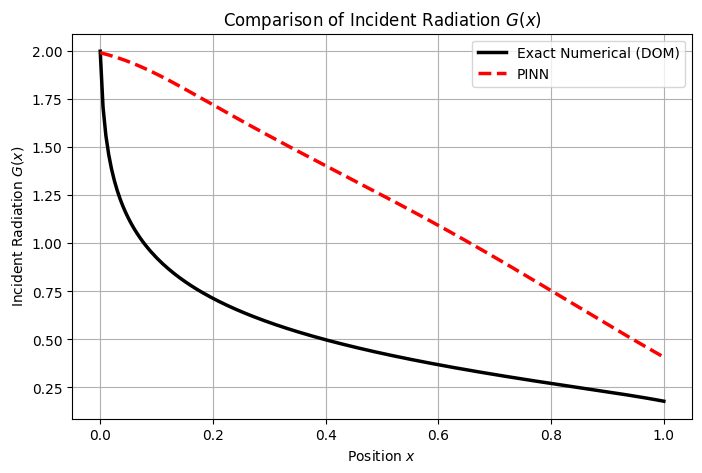

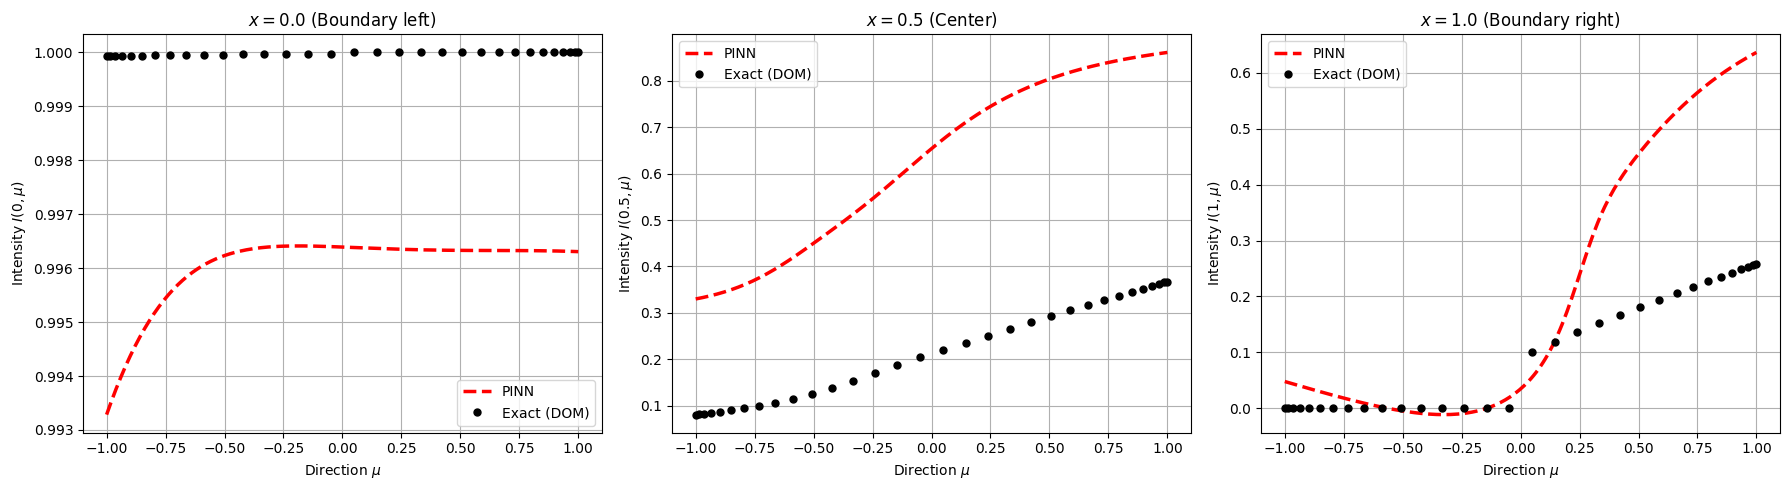

In [9]:
# 1. Discrete Ordinates Method (DOM) Solver for the 1D RTE
M = 200  # Number of grid points in space
x_grid = np.linspace(0.0, 1.0, M)
dx = x_grid[1] - x_grid[0]
eps = 1e-6
sigma = 1.0 / (x_grid + eps)

N_dom = 32  # Number of angles
dom_nodes, dom_weights = np.polynomial.legendre.leggauss(N_dom)

G_exact = np.zeros(M)
I_exact = np.zeros((N_dom, M))

# Source Iteration Loop
for i_iter in range(1000):
    G_old = G_exact.copy()
    for i in range(N_dom):
        mu = dom_nodes[i]
        if mu > 0:
            I_exact[i, 0] = 1.0
            for k in range(1, M):
                I_exact[i, k] = (mu/dx * I_exact[i, k-1] + 0.5 * sigma[k] * G_exact[k]) / (mu/dx + sigma[k])
        else:
            I_exact[i, M-1] = 0.0
            for k in range(M-2, -1, -1):
                I_exact[i, k] = (-mu/dx * I_exact[i, k+1] + 0.5 * sigma[k] * G_exact[k]) / (-mu/dx + sigma[k])
    
    # Update incident radiation G
    G_exact = np.sum(I_exact * dom_weights[:, np.newaxis], axis=0)
    diff = np.max(np.abs(G_exact - G_old))
    if diff < 1e-6:
        print(f"DOM solver converged in {i_iter} iterations.")
        break

# 2. Evaluate PINN model on a regular grid
x_pinn = np.linspace(0.0, 1.0, 200)
mu_pinn = np.linspace(-1.0, 1.0, 200)
X, MU = np.meshgrid(x_pinn, mu_pinn)
grid_inputs = torch.tensor(np.stack([X.ravel(), MU.ravel()], axis=1), dtype=torch.float32).to(device)
with torch.no_grad():
    I_pinn = modele(grid_inputs).cpu().numpy().reshape(X.shape)

# Integrate over mu using trapezoidal rule to get G_pinn
dmu = mu_pinn[1] - mu_pinn[0]
G_pinn = dmu * (0.5 * (I_pinn[0, :] + I_pinn[-1, :]) + np.sum(I_pinn[1:-1, :], axis=0))

# 3. Plot Comparison of Incident Radiation G(x)
plt.figure(figsize=(8, 5))
plt.plot(x_grid, G_exact, 'k-', label="Exact Numerical (DOM)", linewidth=2.5)
plt.plot(x_pinn, G_pinn, 'r--', label="PINN", linewidth=2.5)
plt.xlabel("Position $x$")
plt.ylabel("Incident Radiation $G(x)$")
plt.title("Comparison of Incident Radiation $G(x)$")
plt.legend()
plt.grid(True)
plt.show()

# 4. Plot Comparison of Intensity Profiles I(x, mu)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# x = 0
inputs_x0 = torch.tensor(np.stack([np.zeros_like(mu_pinn), mu_pinn], axis=1), dtype=torch.float32).to(device)
with torch.no_grad():
    I_x0_pinn = modele(inputs_x0).cpu().numpy().flatten()
axes[0].plot(mu_pinn, I_x0_pinn, 'r--', label="PINN", linewidth=2.5)
axes[0].plot(dom_nodes, I_exact[:, 0], 'ko', label="Exact (DOM)", markersize=5)
axes[0].set_title("$x = 0.0$ (Boundary left)")
axes[0].set_xlabel(r"Direction $\mu$")
axes[0].set_ylabel("Intensity $I(0, \mu)$")
axes[0].legend()
axes[0].grid(True)

# x = 0.5
inputs_x05 = torch.tensor(np.stack([np.ones_like(mu_pinn)*0.5, mu_pinn], axis=1), dtype=torch.float32).to(device)
with torch.no_grad():
    I_x05_pinn = modele(inputs_x05).cpu().numpy().flatten()
axes[1].plot(mu_pinn, I_x05_pinn, 'r--', label="PINN", linewidth=2.5)
axes[1].plot(dom_nodes, I_exact[:, M//2], 'ko', label="Exact (DOM)", markersize=5)
axes[1].set_title("$x = 0.5$ (Center)")
axes[1].set_xlabel(r"Direction $\mu$")
axes[1].set_ylabel("Intensity $I(0.5, \mu)$")
axes[1].legend()
axes[1].grid(True)

# x = 1.0
inputs_x1 = torch.tensor(np.stack([np.ones_like(mu_pinn), mu_pinn], axis=1), dtype=torch.float32).to(device)
with torch.no_grad():
    I_x1_pinn = modele(inputs_x1).cpu().numpy().flatten()
axes[2].plot(mu_pinn, I_x1_pinn, 'r--', label="PINN", linewidth=2.5)
axes[2].plot(dom_nodes, I_exact[:, -1], 'ko', label="Exact (DOM)", markersize=5)
axes[2].set_title("$x = 1.0$ (Boundary right)")
axes[2].set_xlabel(r"Direction $\mu$")
axes[2].set_ylabel("Intensity $I(1, \mu)$")
axes[2].legend()
axes[2].grid(True)

plt.tight_layout()
plt.show()
